# Exemples de Workflow 
pour une application de support Ubuntu


In [2]:
from langgraph.graph import StateGraph, START, END
#from langgraph.pregel import Pregel
#from typing import Generic
#from langgraph.graph import CompiledStateGraph
from IPython.display import Image, display
from typing import Literal
from dataclasses import dataclass

@dataclass
class SFState:
    name :str
    desc : str
    input : str
    output : str

@dataclass
class GraphContainer: 
    tag : str
    name: str
    graph : StateGraph

all_graphs = []

### Workflow 1 : Recherche et résolution pré-rapport

- get_info : (Initial) : Le client envoie un message demandant de l'aide pour un problème spécifique.

  - Transition à check_doc : Le problème n'est pas encore vérifié.

  - Transition à solved : Le problème est déjà connu et documenté.

- check_doc : Vérification de la documentation officielle d'Ubuntu et des forums.

  - Transition à doc_found : Le problème est trouvé dans la documentation.

  - Transition à unsolved : Le problème n'est pas documenté, demande d'informations supplémentaires au client.

- doc_found : Solution pré-rapportée trouvée.

  - Transition à solved (Final) : Solution envoyée au client.

- solved (Final) : Le client reçoit une réponse avec les étapes à suivre pour résoudre le problème.

- unsolved (Final) : Le problème nécessite plus d'informations pour être résolu.


Workflow 1: Recherche et résolution pré-rapport
States: {'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts_config=False, func_accepts={}), metadata=None), 'get_info': Node(id='get_info', name='get_info', data=get_info(tags=None, recurse=True, explode_args=False, func_accepts_config=False, func_accepts={}), metadata=None), 'check_doc': Node(id='check_doc', name='check_doc', data=check_doc(tags=None, recurse=True, explode_args=False, func_accepts_config=False, func_accepts={}), metadata=None), 'doc_found': Node(id='doc_found', name='doc_found', data=doc_found(tags=None, recurse=True, explode_args=False, func_accepts_config=False, func_accepts={}), metadata=None), 'solved': Node(id='solved', name='solved', data=solved(tags=None, recurse=True, explode_args=False, func_accepts_config=False, func_accepts={}), metadata=None), 'unsolved': Node(id='unsolved', name='unsolved', data=unsolved(tags=None, recurse=True,

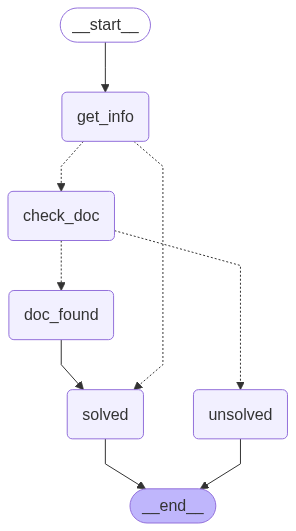

In [ ]:
current_graph = GraphContainer( 
    tag = "search and resolve",
    name = "Workflow 1: Recherche et résolution pré-rapport",
    graph=None)

# Création du graphe d'états pour le Workflow 1
graph_builder = StateGraph(SFState)

# Noeuds du graphe
def get_info (state: SFState) :
    return SFState(name= "get_info", desc="Le client envoie un message demandant de l'aide pour un problème spécifique.")

def check_doc (state: SFState) :
    return SFState(name= "check_doc", desc="Vérification de la documentation officielle d'Ubuntu et des forums.")

def doc_found (state: SFState) :
    return SFState(name= "doc_found", desc="Solution pré-rapportée trouvée.")

def solved (state: SFState) :
    return SFState(name= "solved", desc="Le client reçoit une réponse avec les étapes à suivre pour résoudre le problème.")

def unsolved (state: SFState) :
    return SFState(name= "unsolved", desc="Le problème nécessite plus d'informations pour être résolu.")

# Ajout des états
graph_builder.add_node("get_info", get_info)
graph_builder.add_node("check_doc", check_doc)
graph_builder.add_node("doc_found", doc_found)
graph_builder.add_node("solved", solved)
graph_builder.add_node("unsolved", unsolved)

# Fonctions de transition
def transition_24(state: SFState) -> Literal["check_doc","solved"] :
    if state.output == "doc found" :
        return "solved" 
    else : 
        return "check_doc"

def transition_35(state: SFState) -> Literal["doc_found","unsolved"] :
    if state.output == "problème documenté" :
        return "doc_found" 
    else : 
        return "unsolved"

# Ajout des transitions
graph_builder.add_edge(START, "get_info")
graph_builder.add_conditional_edges("get_info",transition_24)
graph_builder.add_conditional_edges("check_doc", transition_35)
graph_builder.add_edge("doc_found", "solved")
graph_builder.add_edge("solved", END)
graph_builder.add_edge("unsolved", END)

compiled_state_graph = graph_builder.compile()
graph = compiled_state_graph.get_graph()

current_graph.graph = graph

all_graphs.append(current_graph)

# Affichage du workflow
print("Workflow 1: Recherche et résolution pré-rapport")
print("States:", graph.nodes)
print("Edges:", graph.edges)

display(Image(graph.draw_mermaid_png()))

### Workflow 2 : Collecte de données pour un rapport

- E1 (Initial) : Le client envoie un message demandant de l'aide pour un problème spécifique.
    - Transition à E2 : Demande d'informations complémentaires.

- E2 : Demande d'informations complémentaires au client.
    - Transition à E3 : Informations reçues.
    - Transition à E6 (Final) : Informations insuffisantes reçues.

- E3 : Collecte et analyse des données supplémentaires.
    - Transition à E4 : Cause du problème identifiée.
    - Transition à E2 : Besoin de plus d'informations.

- E4 : Rédaction d'un rapport détaillé.
    - Transition à E5 (Final) : Rapport envoyé au client.

- E5 (Final) : Le client reçoit un rapport détaillé avec les étapes à suivre pour résoudre le problème.

- E6 (Final) : Informations insuffisantes pour continuer.


In [4]:
from langgraph.graph import StateGraph, END

# Création du graphe d'états pour le Workflow 2
workflow2 = StateGraph("Workflow 2: Collecte de données pour un rapport")

# Ajout des états
workflow2.add_node("E1", "Le client envoie un message demandant de l'aide pour un problème spécifique.")
workflow2.add_node("E2", "Demande d'informations complémentaires au client.")
workflow2.add_node("E3", "Collecte et analyse des données supplémentaires.")
workflow2.add_node("E4", "Rédaction d'un rapport détaillé.")
workflow2.add_node("E5", "Le client reçoit un rapport détaillé avec les étapes à suivre pour résoudre le problème.")
workflow2.add_node("E6", "Informations insuffisantes reçues.")

# Ajout des transitions
workflow2.add_edge("E1", "E2")
workflow2.add_conditional_edges(
    "E2",
    lambda x: "E3" if x.get("informations suffisantes") else "E6",
    ["E3", "E6"]
)
workflow2.add_conditional_edges(
    "E3",
    lambda x: "E4" if x.get("cause identifiée") else "E2",
    ["E4", "E2"]
)
workflow2.add_edge("E4", "E5")
workflow2.add_edge("E5", END)
workflow2.add_edge("E6", END)

# Configuration des points d'entrée et de sortie
workflow2.set_entry_point("E1")
workflow2.set_finish_point("E5")

# Affichage du workflow
print("Workflow 2: Collecte de données pour un rapport")
print("States:", workflow2.nodes)
print("Edges:", workflow2.edges)

display(Image(graph.draw_mermaid_png()))

/home/nicolascassonnet/Documents/WORK/SmartFix/Workflows_init/.venv_wkf/lib/python3.12/site-packages/langgraph/graph/state.py:99: UserWarning: Invalid state_schema: Workflow 2: Collecte de données pour un rapport. Expected a type or Annotated[type, reducer]. Please provide a valid schema to ensure correct updates.
 See: https://langchain-ai.github.io/langgraph/reference/graphs/#stategraph
  warnings.warn(


TypeError: Expected a Runnable, callable or dict.Instead got an unsupported type: <class 'str'>

### Workflow 3 : Analyse de logs

- E1 (Initial) : Le client envoie un message demandant de l'aide pour un problème spécifique.
    - Transition à E2 : Demande de logs du système.

- E2 : Demande de logs du système au client.
    - Transition à E3 : Logs reçus.
    - Transition à E5 (Final) : Logs non reçus.

- E3 : Analyse des logs pour identifier la cause du problème.
    - Transition à E4 (Final) : Cause identifiée, solution envoyée.
    - Transition à E2 : Besoin de plus de logs.

- E4 (Final) : Le client reçoit une réponse avec les étapes à suivre pour résoudre le problème.

- E5 (Final) : Logs insuffisants pour identifier le problème.


In [ ]:
from langgraph.graph import StateGraph, END

# Création du graphe d'états pour le Workflow 3
workflow3 = StateGraph("Workflow 3: Analyse de logs")

# Ajout des états
workflow3.add_node("E1", "Le client envoie un message demandant de l'aide pour un problème spécifique.")
workflow3.add_node("E2", "Demande de logs du système au client.")
workflow3.add_node("E3", "Analyse des logs pour identifier la cause du problème.")
workflow3.add_node("E4", "Le client reçoit une réponse avec les étapes à suivre pour résoudre le problème.")
workflow3.add_node("E5", "Logs insuffisants pour identifier le problème.")

# Ajout des transitions
workflow3.add_edge("E1", "E2")
workflow3.add_conditional_edges(
    "E2",
    lambda x: "E3" if x.get("logs reçus") else "E5",
    ["E3", "E5"]
)
workflow3.add_conditional_edges(
    "E3",
    lambda x: "E4" if x.get("cause identifiée") else "E2",
    ["E4", "E2"]
)
workflow3.add_edge("E4", END)
workflow3.add_edge("E5", END)

# Configuration des points d'entrée et de sortie
workflow3.set_entry_point("E1")
workflow3.set_finish_point("E4")

# Affichage du workflow
print("Workflow 3: Analyse de logs")
print("States:", workflow3.nodes)
print("Edges:", workflow3.edges)

### Workflow 4 : Résolution d'un problème de configuration

- E1 (Initial) : Le client envoie un message demandant de l'aide pour un problème spécifique lié à la configuration du système.
    - Transition à E2 : Demande d'informations sur la configuration actuelle.

- E2 : Demande d'informations sur la configuration actuelle.
    - Transition à E3 : Informations reçues.
    - Transition à E5 (Final) : Informations insuffisantes reçues.

- E3 : Analyse des informations et ajustement de la configuration.
    - Transition à E4 (Final) : Configuration ajustée, solution envoyée.
    - Transition à E2 : Besoin de plus d'informations.

- E4 (Final) : Le client reçoit une réponse avec les étapes à suivre pour résoudre le problème.

- E5 (Final) : Informations insuffisantes pour ajuster la configuration.


In [ ]:
from langgraph.graph import StateGraph, END

# Création du graphe d'états pour le Workflow 4
workflow4 = StateGraph("Workflow 4: Résolution d'un problème de configuration")

# Ajout des états
workflow4.add_node("E1", "Le client envoie un message demandant de l'aide pour un problème spécifique lié à la configuration du système.")
workflow4.add_node("E2", "Demande d'informations sur la configuration actuelle.")
workflow4.add_node("E3", "Analyse des informations et ajustement de la configuration.")
workflow4.add_node("E4", "Le client reçoit une réponse avec les étapes à suivre pour résoudre le problème.")
workflow4.add_node("E5", "Informations insuffisantes pour ajuster la configuration.")

# Ajout des transitions
workflow4.add_edge("E1", "E2")
workflow4.add_conditional_edges(
    "E2",
    lambda x: "E3" if x.get("informations suffisantes") else "E5",
    ["E3", "E5"]
)
workflow4.add_conditional_edges(
    "E3",
    lambda x: "E4" if x.get("configuration ajustée") else "E2",
    ["E4", "E2"]
)
workflow4.add_edge("E4", END)
workflow4.add_edge("E5", END)

# Configuration des points d'entrée et de sortie
workflow4.set_entry_point("E1")
workflow4.set_finish_point("E4")

# Affichage du workflow
print("Workflow 4: Résolution d'un problème de configuration")
print("States:", workflow4.nodes)
print("Edges:", workflow4.edges)

### Workflow 5 : Résolution d'un problème de sécurité

- E1 (Initial) : Le client envoie un message demandant de l'aide pour un problème spécifique lié à la sécurité.
    - Transition à E2 : Demande d'informations sur les comportements actuels.

- E2 : Demande d'informations sur les comportements actuels.
    - Transition à E3 : Informations reçues.
    - Transition à E5 (Final) : Informations insuffisantes reçues.

- E3 : Analyse des informations et ajustement de la configuration.
    - Transition à E4 (Final) : Problème de sécurité résolu, solution envoyée.
    - Transition à E2 : Besoin de plus d'informations.

- E4 (Final) : Le client reçoit une réponse avec les étapes à suivre pour résoudre le problème.

- E5 (Final) : Informations insuffisantes pour résoudre le problème de sécurité.


In [ ]:
from langgraph.graph import StateGraph, END

# Création du graphe d'états pour le Workflow 5
workflow5 = StateGraph("Workflow 5: Résolution d'un problème de sécurité")

# Ajout des états
workflow5.add_node("E1", "Le client envoie un message demandant de l'aide pour un problème spécifique lié à la sécurité.")
workflow5.add_node("E2", "Demande d'informations sur les comportements actuels.")
workflow5.add_node("E3", "Analyse des informations et ajustement de la configuration.")
workflow5.add_node("E4", "Le client reçoit une réponse avec les étapes à suivre pour résoudre le problème.")
workflow5.add_node("E5", "Informations insuffisantes pour résoudre le problème de sécurité.")

# Ajout des transitions
workflow5.add_edge("E1", "E2")
workflow5.add_conditional_edges(
    "E2",
    lambda x: "E3" if x.get("informations suffisantes") else "E5",
    ["E3", "E5"]
)
workflow5.add_conditional_edges(
    "E3",
    lambda x: "E4" if x.get("problème résolu") else "E2",
    ["E4", "E2"]
)
workflow5.add_edge("E4", END)
workflow5.add_edge("E5", END)

# Configuration des points d'entrée et de sortie
workflow5.set_entry_point("E1")
workflow5.set_finish_point("E4")

# Affichage du workflow
print("Workflow 5: Résolution d'un problème de sécurité")
print("States:", workflow5.nodes)
print("Edges:", workflow5.edges)

### Workflow 6 : Diagnostic et résolution des bugs

- E1 (Initial) : Le client signale un bug.
    - Transition à E2 : Demande d'informations supplémentaires.

- E2 : Demande d'informations supplémentaires.
    - Transition à E3 : Informations reçues.
    - Transition à E6 (Final) : Informations insuffisantes reçues.

- E3 : Analyse des logs et des informations fournies.
    - Transition à E4 : Cause du bug identifiée.
    - Transition à E2 : Besoin de plus d'informations.

- E4 : Instructions pour appliquer un correctif ou contourner le problème.
    - Transition à E5 (Final) : Vérification avec le client si le bug est résolu.
    - Transition à E7 (Final) : Le bug n'est pas résolu.

- E5 (Final) : Le bug est résolu.

- E6 (Final) : Informations insuffisantes pour diagnostiquer le bug.

- E7 (Final) : Le bug n'est pas résolu, retour à l'état E2 pour plus d'informations.


In [ ]:
from langgraph.graph import StateGraph, END

# Création du graphe d'états pour le Workflow 6
workflow6 = StateGraph("Workflow 6: Diagnostic et résolution des bugs")

# Ajout des états
workflow6.add_node("E1", "Le client signale un bug.")
workflow6.add_node("E2", "Demande d'informations supplémentaires.")
workflow6.add_node("E3", "Analyse des logs et des informations fournies.")
workflow6.add_node("E4", "Instructions pour appliquer un correctif ou contourner le problème.")
workflow6.add_node("E5", "Le bug est résolu.")
workflow6.add_node("E6", "Informations insuffisantes pour diagnostiquer le bug.")
workflow6.add_node("E7", "Le bug n'est pas résolu.")

# Ajout des transitions
workflow6.add_edge("E1", "E2")
workflow6.add_conditional_edges(
    "E2",
    lambda x: "E3" if x.get("informations suffisantes") else "E6",
    ["E3", "E6"]
)
workflow6.add_conditional_edges(
    "E3",
    lambda x: "E4" if x.get("cause identifiée") else "E2",
    ["E4", "E2"]
)
workflow6.add_conditional_edges(
    "E4",
    lambda x: "E5" if x.get("bug résolu") else "E7",
    ["E5", "E7"]
)
workflow6.add_edge("E5", END)
workflow6.add_edge("E6", END)
workflow6.add_edge("E7", END)

# Configuration des points d'entrée et de sortie
workflow6.set_entry_point("E1")
workflow6.set_finish_point("E5")

# Affichage du workflow
print("Workflow 6: Diagnostic et résolution des bugs")
print("States:", workflow6.nodes)
print("Edges:", workflow6.edges)

### Workflow 7 : Optimisation des performances du système

- E1 (Initial) : Le client signale des problèmes de performance.
    - Transition à E2 : Demande d'informations supplémentaires.

- E2 : Demande d'informations supplémentaires.
    - Transition à E3 : Informations reçues.
    - Transition à E6 (Final) : Informations insuffisantes reçues.

- E3 : Analyse des informations pour identifier les goulots d'étranglement.
    - Transition à E4 : Recommandations pour optimiser les performances.
    - Transition à E2 : Besoin de plus d'informations.

- E4 : Vérification avec le client si les performances se sont améliorées.
    - Transition à E5 (Final) : Les performances se sont améliorées.
    - Transition à E7 (Final) : Les performances ne se sont pas améliorées.

- E5 (Final) : Les performances se sont améliorées.
 
- E6 (Final) : Informations insuffisantes pour optimiser les performances.

- E7 (Final) : Les performances ne se sont pas améliorées, retour à l'état E2 pour plus d'informations.


In [ ]:
from langgraph.graph import StateGraph, END

# Création du graphe d'états pour le Workflow 7
workflow7 = StateGraph("Workflow 7: Optimisation des performances du système")

# Ajout des états
workflow7.add_node("E1", "Le client signale des problèmes de performance.")
workflow7.add_node("E2", "Demande d'informations supplémentaires.")
workflow7.add_node("E3", "Analyse des informations pour identifier les goulots d'étranglement.")
workflow7.add_node("E4", "Vérification avec le client si les performances se sont améliorées.")
workflow7.add_node("E5", "Les performances se sont améliorées.")
workflow7.add_node("E6", "Informations insuffisantes pour optimiser les performances.")
workflow7.add_node("E7", "Les performances ne se sont pas améliorées.")

# Ajout des transitions
workflow7.add_edge("E1", "E2")
workflow7.add_conditional_edges(
    "E2",
    lambda x: "E3" if x.get("informations suffisantes") else "E6",
    ["E3", "E6"]
)
workflow7.add_conditional_edges(
    "E3",
    lambda x: "E4" if x.get("recommandations fournies") else "E2",
    ["E4", "E2"]
)
workflow7.add_conditional_edges(
    "E4",
    lambda x: "E5" if x.get("performances améliorées") else "E7",
    ["E5", "E7"]
)
workflow7.add_edge("E5", END)
workflow7.add_edge("E6", END)
workflow7.add_edge("E7", END)

# Configuration des points d'entrée et de sortie
workflow7.set_entry_point("E1")
workflow7.set_finish_point("E5")

# Affichage du workflow
print("Workflow 7: Optimisation des performances du système")
print("States:", workflow7.nodes)
print("Edges:", workflow7.edges)

### Workflow 8 : Évaluation et implémentation de nouvelles fonctionnalités

- E1 (Initial) : Le client demande une nouvelle fonctionnalité ou une amélioration.
    - Transition à E2 : Enregistrement de la demande.

- E2 : Enregistrement de la demande et transmission à l'équipe de développement.
    - Transition à E3 : Demande enregistrée.

- E3 : Évaluation de la faisabilité et de l'impact de la nouvelle fonctionnalité.
    - Transition à E4 : Fonctionnalité approuvée.
    - Transition à E5 (Final) : Fonctionnalité rejetée.

- E4 : Planification de la fonctionnalité pour une future mise à jour.
    - Transition à E6 (Final) : Information du client sur l'état de sa demande.

- E5 (Final) : La fonctionnalité n'est pas approuvée.

- E6 (Final) : Le client est informé de l'état de sa demande et des prochaines étapes.


In [ ]:
from langgraph.graph import StateGraph, END

# Création du graphe d'états pour le Workflow 8
workflow8 = StateGraph("Workflow 8: Évaluation et implémentation de nouvelles fonctionnalités")

# Ajout des états
workflow8.add_node("E1", "Le client demande une nouvelle fonctionnalité ou une amélioration.")
workflow8.add_node("E2", "Enregistrement de la demande et transmission à l'équipe de développement.")
workflow8.add_node("E3", "Évaluation de la faisabilité et de l'impact de la nouvelle fonctionnalité.")
workflow8.add_node("E4", "Planification de la fonctionnalité pour une future mise à jour.")
workflow8.add_node("E5", "La fonctionnalité n'est pas approuvée.")
workflow8.add_node("E6", "Le client est informé de l'état de sa demande et des prochaines étapes.")

# Ajout des transitions
workflow8.add_edge("E1", "E2")
workflow8.add_edge("E2", "E3")
workflow8.add_conditional_edges(
    "E3",
    lambda x: "E4" if x.get("fonctionnalité approuvée") else "E5",
    ["E4", "E5"]
)
workflow8.add_edge("E4", "E6")
workflow8.add_edge("E5", END)
workflow8.add_edge("E6", END)

# Configuration des points d'entrée et de sortie
workflow8.set_entry_point("E1")
workflow8.set_finish_point("E6")

# Affichage du workflow
print("Workflow 8: Évaluation et implémentation de nouvelles fonctionnalités")
print("States:", workflow8.nodes)
print("Edges:", workflow8.edges)

### Workflow 9 : Fourniture d'informations et de documentation

- E1 (Initial) : Le client demande des informations supplémentaires ou de la documentation.
    - Transition à E2 : Fourniture de liens vers la documentation officielle.

- E2 : Fourniture de liens vers la documentation officielle ou des guides d'utilisation.
    - Transition à E3 : Documentation fournie.
    - Transition à E4 : Documentation insuffisante.

- E3 (Final) : Le client est satisfait des ressources fournies.

- E4 : Création d'une demande pour mettre à jour la documentation.
    - Transition à E5 (Final) : Information du client sur les mises à jour futures.

- E5 (Final) : Le client est informé des ressources disponibles et des mises à jour futures.


In [ ]:
from langgraph.graph import StateGraph, END

# Création du graphe d'états pour le Workflow 9
workflow9 = StateGraph("Workflow 9: Fourniture d'informations et de documentation")

# Ajout des états
workflow9.add_node("E1", "Le client demande des informations supplémentaires ou de la documentation.")
workflow9.add_node("E2", "Fourniture de liens vers la documentation officielle ou des guides d'utilisation.")
workflow9.add_node("E3", "Le client est satisfait des ressources fournies.")
workflow9.add_node("E4", "Création d'une demande pour mettre à jour la documentation.")
workflow9.add_node("E5", "Le client est informé des ressources disponibles et des mises à jour futures.")

# Ajout des transitions
workflow9.add_edge("E1", "E2")
workflow9.add_conditional_edges(
    "E2",
    lambda x: "E3" if x.get("documentation fournie") else "E4",
    ["E3", "E4"]
)
workflow9.add_edge("E4", "E5")
workflow9.add_edge("E3", END)
workflow9.add_edge("E5", END)

# Configuration des points d'entrée et de sortie
workflow9.set_entry_point("E1")
workflow9.set_finish_point("E3")

# Affichage du workflow
print("Workflow 9: Fourniture d'informations et de documentation")
print("States:", workflow9.nodes)
print("Edges:", workflow9.edges)

Ces parcours permettent de gérer différentes issues possibles à chaque étape, offrant ainsi une flexibilité accrue dans la gestion des workflows.